In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np

# 讀取資料
user_data = pd.read_csv('user_data.csv')
dp001_prac = pd.read_csv('dp001_prac.csv')
dp001_exam = pd.read_csv('dp001_exam.csv')
dp001_review = pd.read_csv('dp001_review.csv')
dp001_review_plus = pd.read_csv('dp001_review_plus.csv')

In [2]:
# Select the relevant columns for standardization (Chinese, Math, English scores)
score_columns = ['chinese_score', 'math_score', 'english_score']
scores = user_data[score_columns]

# Apply standardization
scaler = StandardScaler()
standardized_scores = scaler.fit_transform(scores)

# Create a DataFrame with standardized scores
standardized_df = pd.DataFrame(standardized_scores, columns=score_columns)

# Calculate the total of standardized scores and sort
standardized_df['total_score'] = standardized_df.sum(axis=1)
standardized_df['user_sn'] = user_data['user_sn']  # Add user identifiers
sorted_standardized_df = standardized_df.sort_values(by='total_score', ascending=False)

# Determine the number of rows for the top and bottom quartiles
top_quarter_count = len(sorted_standardized_df) // 4
bottom_quarter_count = len(sorted_standardized_df) - top_quarter_count

# Select the top and bottom quartiles
top_quarter_users = sorted_standardized_df.head(top_quarter_count)['user_sn'].tolist()
bottom_quarter_users = sorted_standardized_df.tail(top_quarter_count)['user_sn'].tolist()

# Output the top and bottom quarter user_sn lists
# top_quarter_users, bottom_quarter_users
sorted_standardized_df


,chinese_score,math_score,english_score,total_score,user_sn
33,1.648623,1.961172,0.965840,4.575635,87634
18,0.658836,2.766552,1.093632,4.519021,32737
7,1.648623,1.692712,0.965840,4.307175,11312
35,1.066396,1.961172,0.965840,3.993408,106042
69,1.241064,1.155792,1.093632,3.490488,243283
...,...,...,...,...,...
37,-1.844742,-1.528810,-1.462212,-4.835764,106735
57,-2.252301,-1.260350,-1.462212,-4.974863,200920
63,-1.670073,-1.528810,-2.186368,-5.385251,216784
19,-1.844742,-1.528810,-2.441953,-5.815504,38371


將三科成績合併，並做標準化，取前1/4與後1/4的user

In [3]:
# Filter rows where 'subject_name' is '英語108'
filtered_english_prac = dp001_prac[dp001_prac['subject_name'] == '英語108']

# Define a function to calculate total answers and correct answers, handling empty or non-numeric values
def calculate_answer_data_for_english(binary_res_series):
    total_answers = []
    correct_answers = []
    
    for res in binary_res_series:
        # Split by the delimiter to get individual answer results and handle any non-numeric parts
        answers = [int(x) if x.isdigit() else 0 for x in res.split('@XX@')]  # Treat non-numeric as 0 (incorrect)
        total_answers.append(len(answers))             # Total number of answers
        correct_answers.append(sum(answers))           # Number of correct answers
    return total_answers, correct_answers

# Apply the function to 'binary_res' column and store results in new columns
filtered_english_prac['total_answers'], filtered_english_prac['correct_answers'] = calculate_answer_data_for_english(filtered_english_prac['binary_res'])

# Group by 'user_sn' and aggregate total answer counts and correct counts
user_grouped_english_data = filtered_english_prac.groupby('user_sn').agg(
    total_answers=('total_answers', 'sum'),
    correct_answers=('correct_answers', 'sum')
)

# Calculate accuracy rate for each user
user_grouped_english_data['accuracy_rate'] = (user_grouped_english_data['correct_answers'] / 
                                              user_grouped_english_data['total_answers']) * 100

# Perform Min-Max normalization on accuracy rate
min_accuracy = user_grouped_english_data['accuracy_rate'].min()
max_accuracy = user_grouped_english_data['accuracy_rate'].max()

user_grouped_english_data['normalized_accuracy_rate'] = (
    (user_grouped_english_data['accuracy_rate'] - min_accuracy) / 
    (max_accuracy - min_accuracy)
)

# Sort results by normalized accuracy rate and display
user_grouped_english_data_sorted = user_grouped_english_data.sort_values(by='normalized_accuracy_rate')

# Determine the number of users for the top and bottom quartiles
top_quarter_count_english = len(user_grouped_english_data_sorted) // 4
bottom_quarter_count_english = top_quarter_count_english

# Correcting the approach: Top quarter should be the highest accuracy rates, bottom quarter the lowest

# Top 1/4: highest normalized accuracy rate
top_quarter_users_english = user_grouped_english_data_sorted.tail(top_quarter_count_english).index.tolist()

# Bottom 1/4: lowest normalized accuracy rate
bottom_quarter_users_english = user_grouped_english_data_sorted.head(bottom_quarter_count_english).index.tolist()

# Output corrected lists
# top_quarter_users_english, bottom_quarter_users_english

# Identify the overlap between the English top/bottom quartiles and the overall top/bottom quartiles

# Using previously computed top/bottom quartiles for overall standardized scores
overall_top_quarter_users = set(top_quarter_users)  # from the initial calculation
overall_bottom_quarter_users = set(bottom_quarter_users)

# Convert English top/bottom quartiles to sets for comparison
english_top_quarter_set = set(top_quarter_users_english)
english_bottom_quarter_set = set(bottom_quarter_users_english)

# Find intersections for both top and bottom quartiles
top_quarter_overlap = overall_top_quarter_users.intersection(english_top_quarter_set)
bottom_quarter_overlap = overall_bottom_quarter_users.intersection(english_bottom_quarter_set)

# Output the overlapping user_sn for top and bottom quartiles
top_quarter_overlap, bottom_quarter_overlap

C:\Users\USER\AppData\Local\Temp\ipykernel_14976\2395276364.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_english_prac['total_answers'], filtered_english_prac['correct_answers'] = calculate_answer_data_for_english(filtered_english_prac['binary_res'])
C:\Users\USER\AppData\Local\Temp\ipykernel_14976\2395276364.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_english_prac['total_answers'], filtered_english_prac['correct_answers'] = calculate_answer_data_for_english(filtered_englis

({4561, 316786}, {232372})

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Filter rows where 'subject_name' is either '國語文' or '國語文108' for Chinese subject data
filtered_chinese_prac = dp001_prac[dp001_prac['subject_name'].isin(['國語文', '國語文108'])]

# Define a function to calculate total answers and correct answers, handling empty or non-numeric values
def calculate_answer_data_for_chinese(binary_res_series):
    total_answers = []
    correct_answers = []
    
    for res in binary_res_series:
        # Split by the delimiter to get individual answer results and handle any non-numeric parts
        answers = [int(x) if x.isdigit() else 0 for x in res.split('@XX@')]  # Treat non-numeric as 0 (incorrect)
        total_answers.append(len(answers))             # Total number of answers
        correct_answers.append(sum(answers))           # Number of correct answers
    return total_answers, correct_answers

# Apply this function to 'binary_res' column and store results in new columns
filtered_chinese_prac['total_answers'], filtered_chinese_prac['correct_answers'] = calculate_answer_data_for_chinese(filtered_chinese_prac['binary_res'])

# Group by 'user_sn' and aggregate total answer counts and correct counts
user_grouped_chinese_data = filtered_chinese_prac.groupby('user_sn').agg(
    total_answers=('total_answers', 'sum'),
    correct_answers=('correct_answers', 'sum')
)

# Calculate accuracy rate for each user
user_grouped_chinese_data['accuracy_rate'] = (user_grouped_chinese_data['correct_answers'] / 
                                              user_grouped_chinese_data['total_answers']) * 100

# Perform min-max normalization on 'accuracy_rate'
scaler = MinMaxScaler()
user_grouped_chinese_data['normalized_accuracy_rate'] = scaler.fit_transform(user_grouped_chinese_data[['accuracy_rate']])

# Sort and display the results
user_grouped_chinese_data_sorted = user_grouped_chinese_data.sort_values('normalized_accuracy_rate')

# Calculate the number of entries for top and bottom quartiles
top_quarter_count_chinese = len(user_grouped_chinese_data_sorted) // 4
bottom_quarter_count_chinese = top_quarter_count_chinese

# Select top and bottom quartiles based on normalized accuracy rate in the sorted DataFrame
top_quarter_users_chinese = user_grouped_chinese_data_sorted.tail(top_quarter_count_chinese).index.tolist()
bottom_quarter_users_chinese = user_grouped_chinese_data_sorted.head(bottom_quarter_count_chinese).index.tolist()

# Output the lists of user_sn for both top and bottom quartiles
# top_quarter_users_chinese, bottom_quarter_users_chinese

# Identify the overlap between the Chinese top/bottom quartiles and the overall top/bottom quartiles

# Convert Chinese top/bottom quartiles to sets for comparison
chinese_top_quarter_set = set(top_quarter_users_chinese)
chinese_bottom_quarter_set = set(bottom_quarter_users_chinese)

# Find intersections for both top and bottom quartiles with overall quartiles
top_quarter_overlap_chinese = overall_top_quarter_users.intersection(chinese_top_quarter_set)
bottom_quarter_overlap_chinese = overall_bottom_quarter_users.intersection(chinese_bottom_quarter_set)

# Output the overlapping user_sn for top and bottom quartiles
top_quarter_overlap_chinese, bottom_quarter_overlap_chinese





C:\Users\USER\AppData\Local\Temp\ipykernel_14976\3895192678.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_chinese_prac['total_answers'], filtered_chinese_prac['correct_answers'] = calculate_answer_data_for_chinese(filtered_chinese_prac['binary_res'])
C:\Users\USER\AppData\Local\Temp\ipykernel_14976\3895192678.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_chinese_prac['total_answers'], filtered_chinese_prac['correct_answers'] = calculate_answer_data_for_chinese(filtered_chines

({14314, 30835, 87634, 149800, 316786},
 {23061, 38371, 128932, 200920, 212767, 311086})

In [5]:
# Filter rows where 'subject_name' is either '數學' or '數學108'
filtered_math_prac = dp001_prac[dp001_prac['subject_name'].isin(['數學', '數學108'])]

# Define a function to calculate total answers and correct answers, handling empty or non-numeric values
def calculate_answer_data_for_math(binary_res_series):
    total_answers = []
    correct_answers = []
    
    for res in binary_res_series:
        # Split by the delimiter to get individual answer results and handle any non-numeric parts
        answers = [int(x) if x.isdigit() else 0 for x in res.split('@XX@')]  # Treat non-numeric as 0 (incorrect)
        total_answers.append(len(answers))             # Total number of answers
        correct_answers.append(sum(answers))           # Number of correct answers
    return total_answers, correct_answers

# Apply this function to 'binary_res' column and store results in new columns
filtered_math_prac['total_answers'], filtered_math_prac['correct_answers'] = calculate_answer_data_for_math(filtered_math_prac['binary_res'])

# Group by 'user_sn' and aggregate total answer counts and correct counts
user_grouped_math_data = filtered_math_prac.groupby('user_sn').agg(
    total_answers=('total_answers', 'sum'),
    correct_answers=('correct_answers', 'sum')
)

# Calculate accuracy rate for each user
user_grouped_math_data['accuracy_rate'] = (user_grouped_math_data['correct_answers'] / user_grouped_math_data['total_answers']) * 100

# Determine the number of users for the top and bottom quartiles in Math data
top_quarter_count_math = len(user_grouped_math_data) // 4
bottom_quarter_count_math = top_quarter_count_math

# Sort the data by accuracy rate and select top and bottom quartiles
user_grouped_math_data_sorted = user_grouped_math_data.sort_values('accuracy_rate')
top_quarter_users_math = user_grouped_math_data_sorted.tail(top_quarter_count_math).index.tolist()
bottom_quarter_users_math = user_grouped_math_data_sorted.head(bottom_quarter_count_math).index.tolist()

# Output the top and bottom quarter user_sn lists for Math subject
# top_quarter_users_math, bottom_quarter_users_math

# Identify the overlap between the Math top/bottom quartiles and the overall top/bottom quartiles

# Convert Math top/bottom quartiles to sets for comparison
math_top_quarter_set = set(top_quarter_users_math)
math_bottom_quarter_set = set(bottom_quarter_users_math)

# Find intersections for both top and bottom quartiles with overall quartiles
top_quarter_overlap_math = overall_top_quarter_users.intersection(math_top_quarter_set)
bottom_quarter_overlap_math = overall_bottom_quarter_users.intersection(math_bottom_quarter_set)

# Output the overlapping user_sn for top and bottom quartiles
top_quarter_overlap_math, bottom_quarter_overlap_math


C:\Users\USER\AppData\Local\Temp\ipykernel_14976\496365556.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_math_prac['total_answers'], filtered_math_prac['correct_answers'] = calculate_answer_data_for_math(filtered_math_prac['binary_res'])
C:\Users\USER\AppData\Local\Temp\ipykernel_14976\496365556.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_math_prac['total_answers'], filtered_math_prac['correct_answers'] = calculate_answer_data_for_math(filtered_math_prac['binary_res'])


({4561, 11312, 17422, 32737, 50836, 243283, 288079, 316786},
 {11303, 14503, 106735, 122299, 122416, 212767})

In [6]:
# 定義 high_score_users 列表
high_score_users = [4561, 316786, 87634, 30835, 14314, 149800, 32737, 11312, 50836, 243283, 17422, 288079]

# 確認 high_score_users 中哪些使用者在 dp001_review 中沒有資料
users_with_data = dp001_review['user_sn'].unique()
missing_high_users = [user for user in high_score_users if user not in users_with_data]

print("沒有資料的使用者:", missing_high_users)


沒有資料的使用者: [87634, 30835, 14314, 149800]


In [7]:
# 定義 high_score_users 列表
low_score_users = [232372, 200920, 38371, 128932, 212767, 23061, 311086, 122416, 122299, 106735, 11303, 14503]

# 確認 high_score_users 中哪些使用者在 dp001_review 中沒有資料
users_with_data = dp001_review['user_sn'].unique()
missing_low_users = [user for user in low_score_users if user not in users_with_data]

print("沒有資料的使用者:", missing_low_users)


沒有資料的使用者: [23061]


In [8]:
# Define high score user group based on provided user_sn list
high_score_users = [4561, 316786, 32737, 11312, 50836, 243283, 17422, 288079]

# Filter dp001_review to include only rows where 'user_sn' is in high_score_users
filtered_high_score_reviews = dp001_review[dp001_review['user_sn'].isin(high_score_users)]

# Select only 'user_sn' and 'review_sn' for output
filtered_high_score_reviews_output = filtered_high_score_reviews[['user_sn', 'review_sn']]
filtered_high_score_reviews_output


,user_sn,review_sn
87,243283,100202316
105,288079,100203540
109,243283,100204289
124,288079,100204506
145,243283,100243562
...,...,...
3833,11312,123776918
3841,11312,123778258
3865,50836,123781741
3866,50836,123781928


高分組觀看的影片代碼

In [9]:
# Define low score user group based on provided user_sn list
low_score_users = [232372, 200920, 38371, 128932, 212767, 311086, 122416, 122299, 106735, 11303, 14503]

# Filter dp001_review to include only rows where 'user_sn' is in low_score_users
filtered_low_score_reviews = dp001_review[dp001_review['user_sn'].isin(low_score_users)]

# Select only 'user_sn' and 'review_sn' for output
filtered_low_score_reviews_output = filtered_low_score_reviews[['user_sn', 'review_sn']]

filtered_low_score_reviews_output

,user_sn,review_sn
11,11303,98083028
14,11303,98084330
18,11303,98156835
20,11303,98157929
21,11303,98159756
...,...,...
3937,122299,124628709
3950,11303,124734204
3958,122299,124772497
3966,106735,124776196


低分組觀看的影片代碼

In [10]:
# Get unique review_sn lists for high and low score groups from the filtered data
high_score_review_sn = filtered_high_score_reviews_output['review_sn'].unique()
low_score_review_sn = filtered_low_score_reviews_output['review_sn'].unique()

# Filter dp001_review_plus to include only rows where 'review_sn' is in either high or low score review_sn lists
filtered_high_score_review_plus = dp001_review_plus[dp001_review_plus['review_sn'].isin(high_score_review_sn)]
filtered_low_score_review_plus = dp001_review_plus[dp001_review_plus['review_sn'].isin(low_score_review_sn)]
filtered_high_score_review_plus

,review_plus_sn,review_sn,view_time,view_action,timestamp,turbo
877,1147668658,100202316,2024-01-15 15:46:55,browse,0.00,NaN
878,1147668849,100202316,2024-01-15 15:47:03,play,0.00,NaN
879,1147669540,100202316,2024-01-15 15:47:32,paused,28.52,NaN
880,1147670873,100202316,2024-01-15 15:48:40,play,28.52,NaN
881,1147672486,100202316,2024-01-15 15:50:11,paused,119.12,NaN
...,...,...,...,...,...,...
68722,1279643536,123782093,2024-05-27 14:11:41,dragstart,1.90,NaN
68723,1279643642,123782093,2024-05-27 14:11:43,dragright,308.43,NaN
68724,1279643711,123782093,2024-05-27 14:11:46,play,308.43,NaN
68725,1279643737,123782093,2024-05-27 14:11:46,speedup,308.86,1.5


In [11]:
filtered_low_score_review_plus

,review_plus_sn,review_sn,view_time,view_action,timestamp,turbo
114,1138401899,98083028,2024-01-02 15:50:50,browse,0.00,NaN
115,1138401977,98083028,2024-01-02 15:50:52,continue,74.87,NaN
116,1138402066,98083028,2024-01-02 15:50:54,play,74.87,NaN
117,1138404860,98083028,2024-01-02 15:52:19,end,159.34,NaN
128,1138410456,98084330,2024-01-02 15:54:38,browse,0.00,NaN
...,...,...,...,...,...,...
69900,1284755849,124781105,2024-05-31 10:06:46,paused,169.00,NaN
69901,1284755850,124781105,2024-05-31 10:06:46,chkptstart,169.00,NaN
69902,1284756341,124781105,2024-05-31 10:07:00,chkptend,169.00,NaN
69903,1284756385,124781105,2024-05-31 10:07:01,play,170.50,NaN


依序是高分組、低分組的觀看影片行為

In [12]:
# Prepare to create sequences of 'view_action' per 'review_sn' for high and low score groups

# Group high score and low score review_plus data by 'review_sn' and aggregate 'view_action' as sequences
high_score_review_sequences = filtered_high_score_review_plus.groupby('review_sn')['view_action'].apply(lambda x: '->'.join(x)).reset_index()
low_score_review_sequences = filtered_low_score_review_plus.groupby('review_sn')['view_action'].apply(lambda x: '->'.join(x)).reset_index()

# Rename columns for clarity
high_score_review_sequences.columns = ['review_sn', 'high_score_sequence']
low_score_review_sequences.columns = ['review_sn', 'low_score_sequence']


In [13]:
high_score_review_sequences

,review_sn,high_score_sequence
0,100202316,browse->play->paused->play->paused->play->paus...
1,100203540,browse->play->paused->chkptstart->chkptend->pl...
2,100204289,browse->play->paused->chkptstart->chkptend->pl...
3,100204506,browse->play->paused->chkptstart->chkptend->pl...
4,100243562,browse->play->fuscreenon->paused->fuscreenoff-...
...,...,...
314,123776918,browse->fuscreenon->normal->play
315,123778258,browse->continue->play->fuscreenon->paused->pl...
316,123781741,browse->play->paused->dragstart->play->paused-...
317,123781928,browse->speedup->play->paused->dragstart->play...


In [14]:
low_score_review_sequences

,review_sn,low_score_sequence
0,98083028,browse->continue->play->end
1,98084330,browse->play->paused->chkptstart->chkptend->pl...
2,98156835,browse->continue->play->paused->play->end
3,98157929,browse->play->paused->chkptstart->chkptend->pl...
4,98159756,browse->continue->play->paused->chkptstart
...,...,...
657,124628709,browse->continue->play->paused->chkptstart->ch...
658,124734204,browse->play->paused->play->paused->play->paus...
659,124772497,browse->play->normal->paused->play->paused->ch...
660,124776196,browse->continue->play->paused->play->paused->...


依序是高分組、低分組的行為序列

---

In [15]:
# Update the selected actions to reflect the changes
selected_actions_updated = ['play', 'paused', 'normal', 'speedup', 'slowdown', 'dragstart',  'dragright', 'dragleft', 'note']

# Filter the action sequences based on the updated selected actions
def filter_action_sequences_updated(sequences, selected_actions):
    filtered_sequences = []
    for sequence in sequences:
        actions = sequence.split('->')
        filtered_sequence = '->'.join(action for action in actions if action in selected_actions)
        filtered_sequences.append(filtered_sequence)
    return filtered_sequences

# Filter the high and low score action sequences with the updated selected actions
filtered_high_score_sequences_updated = filter_action_sequences_updated(high_score_review_sequences['high_score_sequence'], selected_actions_updated)
filtered_low_score_sequences_updated = filter_action_sequences_updated(low_score_review_sequences['low_score_sequence'], selected_actions_updated)

# Create the new transition count matrices for the updated actions
def create_filtered_transition_count_matrix_updated(sequences, selected_actions):
    transition_count_matrix = np.zeros((len(selected_actions), len(selected_actions)))
    action_to_index = {action: idx for idx, action in enumerate(selected_actions)}

    for sequence in sequences:
        action_list = sequence.split('->')
        for i in range(len(action_list) - 1):
            current_action = action_list[i]
            next_action = action_list[i + 1]
            if current_action in action_to_index and next_action in action_to_index:
                transition_count_matrix[action_to_index[current_action], action_to_index[next_action]] += 1

    return transition_count_matrix

# Create the new transition count matrices for high and low score groups
filtered_high_score_transition_count_matrix_updated = create_filtered_transition_count_matrix_updated(filtered_high_score_sequences_updated, selected_actions_updated)
filtered_low_score_transition_count_matrix_updated = create_filtered_transition_count_matrix_updated(filtered_low_score_sequences_updated, selected_actions_updated)

# Convert to DataFrame for better readability
filtered_high_score_transition_count_df_updated = pd.DataFrame(filtered_high_score_transition_count_matrix_updated, index=selected_actions_updated, columns=selected_actions_updated)
filtered_low_score_transition_count_df_updated = pd.DataFrame(filtered_low_score_transition_count_matrix_updated, index=selected_actions_updated, columns=selected_actions_updated)
filtered_high_score_transition_count_df_updated

,play,paused,normal,speedup,slowdown,dragstart,dragright,dragleft,note
play,4.0,1628.0,59.0,22.0,20.0,3.0,1.0,1.0,0.0
paused,1481.0,39.0,4.0,1.0,1.0,183.0,1.0,2.0,7.0
normal,13.0,68.0,13.0,3.0,30.0,0.0,0.0,0.0,0.0
speedup,11.0,20.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
slowdown,0.0,2.0,50.0,1.0,3.0,0.0,0.0,0.0,0.0
dragstart,22.0,4.0,0.0,0.0,0.0,0.0,43.0,126.0,0.0
dragright,33.0,1.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0
dragleft,111.0,1.0,1.0,0.0,0.0,13.0,0.0,0.0,0.0
note,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


高分組行為轉移次數

In [16]:
filtered_low_score_transition_count_df_updated

,play,paused,normal,speedup,slowdown,dragstart,dragright,dragleft,note
play,12.0,2552.0,150.0,24.0,33.0,9.0,4.0,11.0,0.0
paused,2184.0,191.0,9.0,0.0,2.0,412.0,0.0,8.0,1.0
normal,16.0,134.0,3.0,8.0,30.0,1.0,0.0,1.0,0.0
speedup,10.0,17.0,9.0,1.0,6.0,0.0,0.0,0.0,0.0
slowdown,0.0,9.0,55.0,7.0,0.0,0.0,0.0,0.0,0.0
dragstart,29.0,8.0,1.0,0.0,0.0,5.0,90.0,384.0,0.0
dragright,67.0,5.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0
dragleft,299.0,18.0,0.0,0.0,0.0,84.0,0.0,0.0,0.0
note,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


低分組行為轉移次數

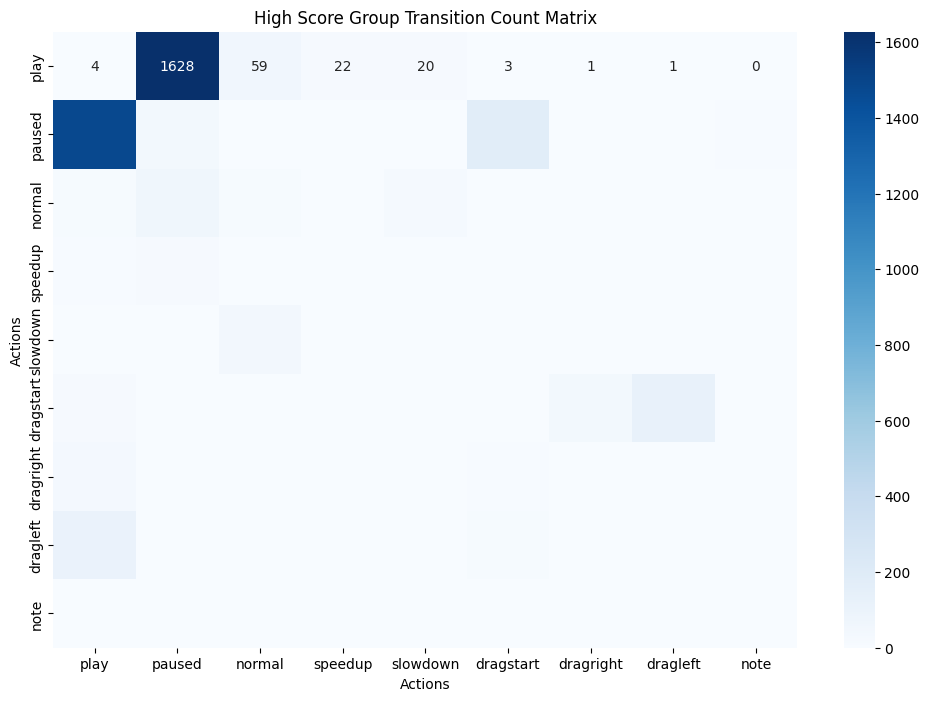

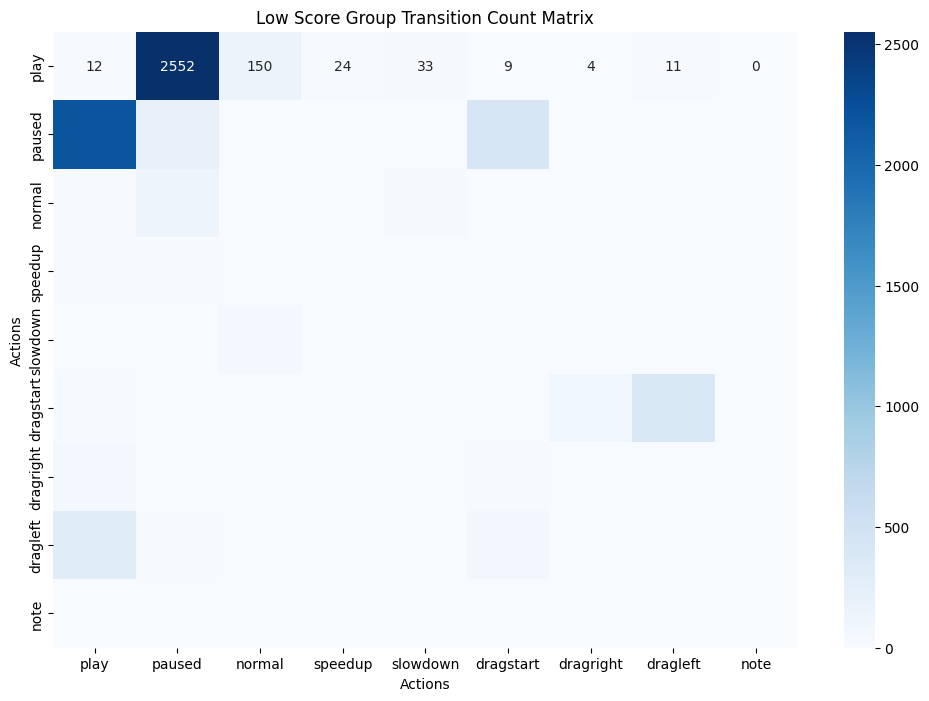

In [17]:
# Heatmap for high score group transition count matrix
plt.figure(figsize=(12, 8))
sns.heatmap(filtered_high_score_transition_count_df_updated, annot=True, cmap='Blues', fmt='g')
plt.title('High Score Group Transition Count Matrix')
plt.xlabel('Actions')
plt.ylabel('Actions')
plt.show()

# Heatmap for low score group transition count matrix
plt.figure(figsize=(12, 8))
sns.heatmap(filtered_low_score_transition_count_df_updated, annot=True, cmap='Blues', fmt='g')
plt.title('Low Score Group Transition Count Matrix')
plt.xlabel('Actions')
plt.ylabel('Actions')
plt.show()


In [70]:
# 高分組和低分組的使用者列表
low_score_users = [232372, 200920, 38371, 128932, 212767, 311086, 122416, 122299, 106735, 11303, 14503]
high_score_users = [4561, 316786, 32737, 11312, 50836, 243283, 17422, 288079]
all_users = high_score_users + low_score_users

# Step 1: 從 dp001_review 中篩選出高低分組的使用者並獲取 review_sn
filtered_reviews = dp001_review[dp001_review['user_sn'].isin(all_users)]
review_sn_list = filtered_reviews['review_sn'].unique()

# Step 2: 創建 review_sn 到 user_sn 的映射
review_to_user_mapping = filtered_reviews.set_index('review_sn')['user_sn']

# Step 3: 在 dp001_review_plus 中篩選出這些 review_sn 的行為數據
filtered_review_plus = dp001_review_plus[dp001_review_plus['review_sn'].isin(review_sn_list)]

# 定義要統計的行為
relevant_actions = ['play', 'paused', 'normal', 'speedup', 'slowdown', 'dragstart',  'dragright', 'dragleft', 'note']

# Step 4: 統計每個 review_sn 的行為次數
action_counts = filtered_review_plus[filtered_review_plus['view_action'].isin(relevant_actions)] \
    .groupby(['review_sn', 'view_action']).size().unstack(fill_value=0)

# 確保所有行為都包含在欄位中，即使次數為 0
action_counts = action_counts.reindex(columns=relevant_actions, fill_value=0)

# Step 5: 使用 review_to_user_mapping 將 review_sn 映射回 user_sn
action_counts['user_sn'] = action_counts.index.map(review_to_user_mapping)

# Step 6: 按 user_sn 聚合行為次數
user_action_counts = action_counts.groupby('user_sn').sum()

# 顯示結果
user_action_counts = pd.DataFrame(user_action_counts)
user_action_counts

view_action,play,paused,normal,speedup,slowdown,dragstart,dragright,dragleft,note
user_sn,,,,,,,,,
4561,5,5,1,0,1,0,0,0,0
11303,142,97,4,1,0,2,1,1,0
11312,435,400,35,6,16,8,0,5,1
14503,518,474,27,1,10,74,6,66,0
17422,12,7,2,1,0,0,0,0,0
32737,358,315,4,7,3,63,25,30,0
38371,79,80,5,0,5,1,0,1,0
50836,125,115,32,6,25,37,8,10,0
106735,143,92,1,0,0,0,0,0,0


各學員在各自觀看的影片的行為統計

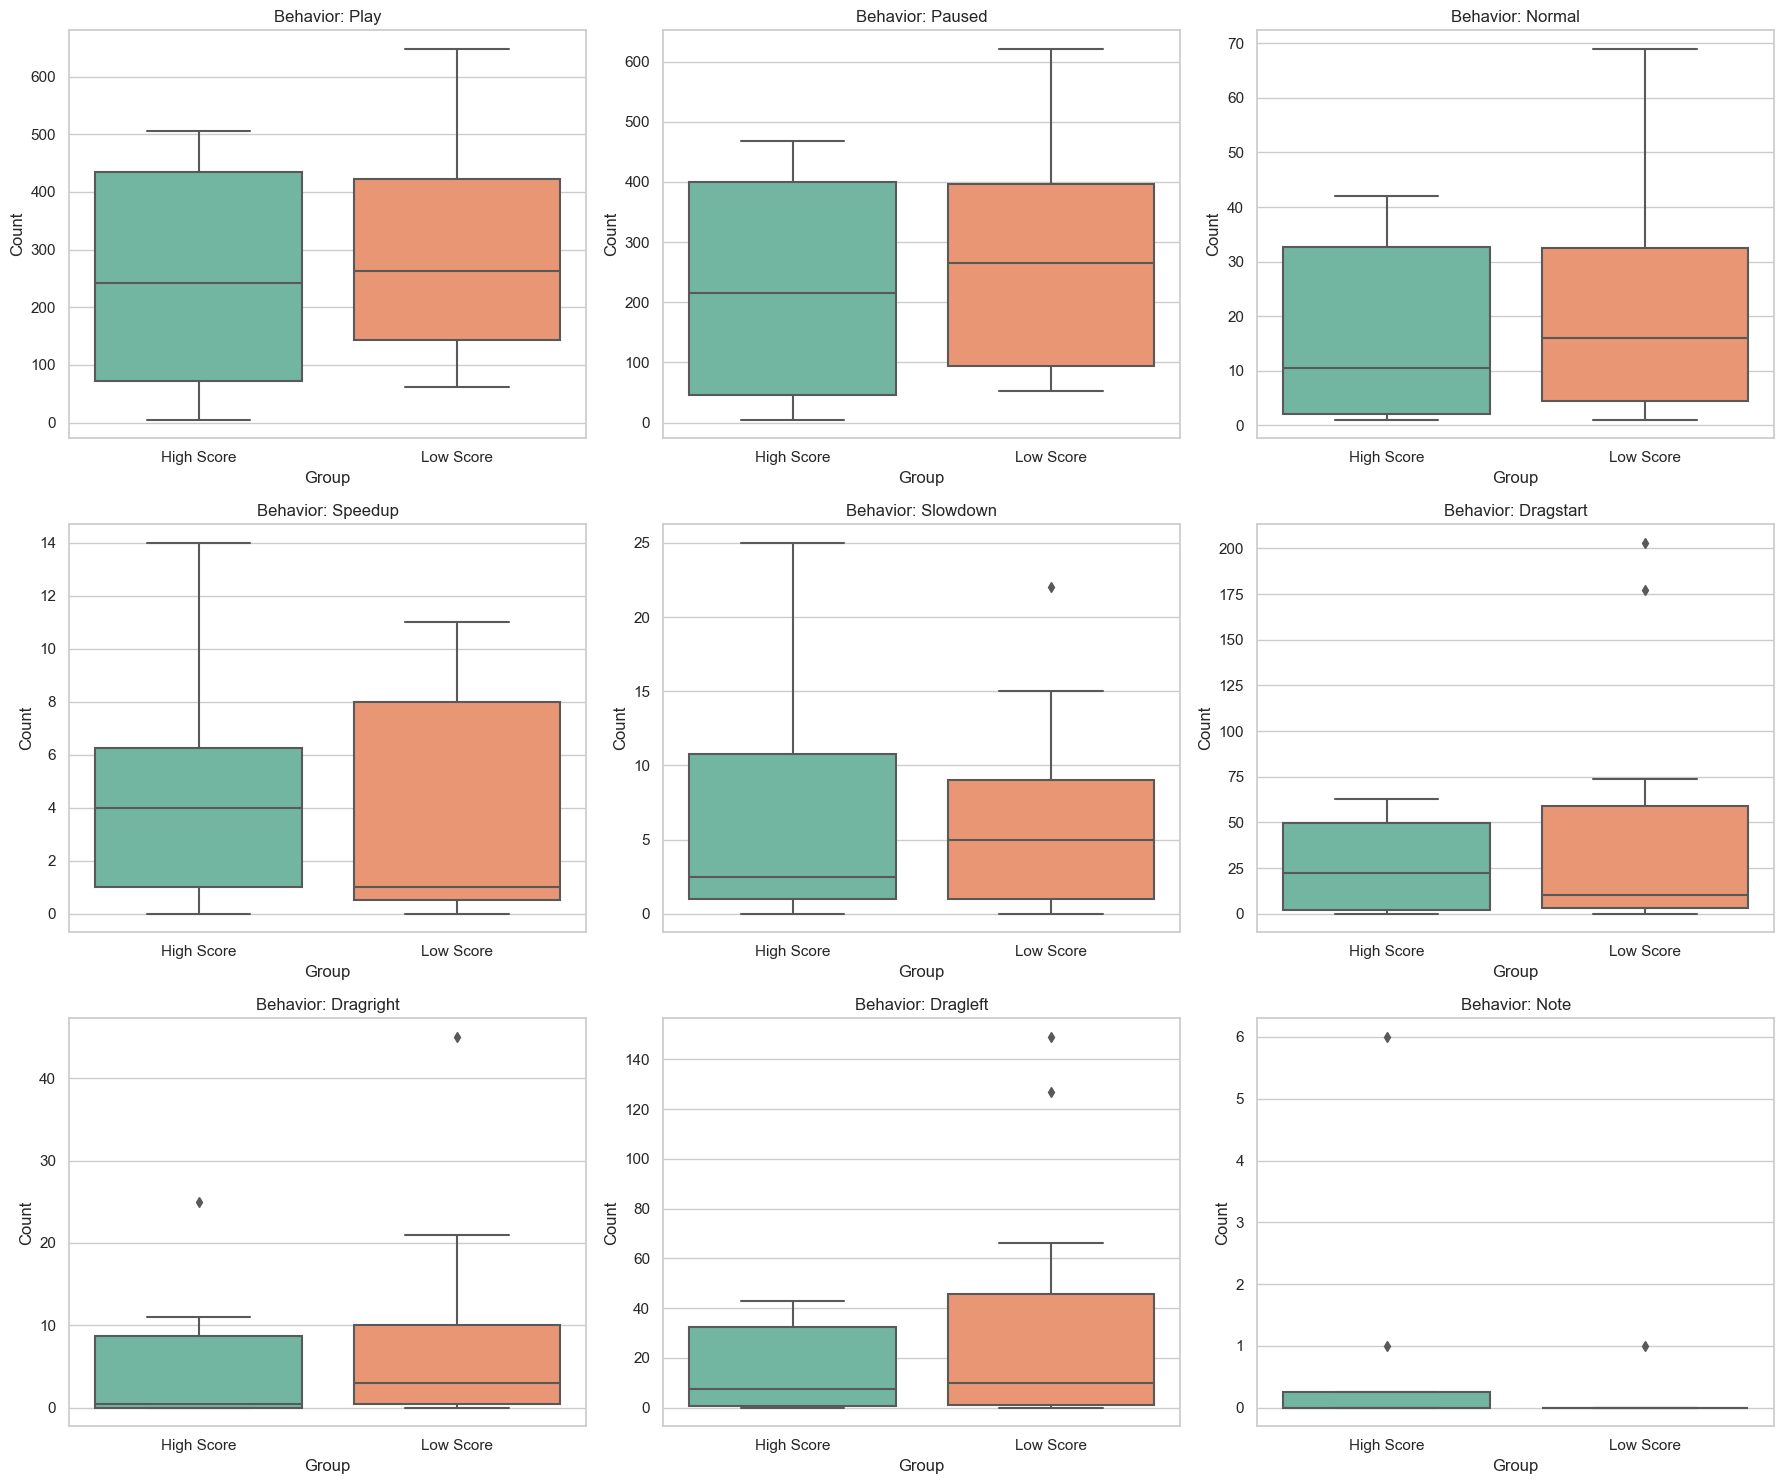

In [69]:
# 確保只取在 user_action_counts 中存在的 user_sn
existing_high_score_users = list(set(high_score_users).intersection(user_action_counts.index))
existing_low_score_users = list(set(low_score_users).intersection(user_action_counts.index))

# 為高分組和低分組的用戶數據添加分組標籤
high_score_data = user_action_counts.loc[existing_high_score_users].assign(group='High Score')
low_score_data = user_action_counts.loc[existing_low_score_users].assign(group='Low Score')

# 合併數據
plot_data = pd.concat([high_score_data, low_score_data]).reset_index()

# 定義行為列表
relevant_actions = ['play', 'paused', 'normal', 'speedup', 'slowdown', 'dragstart',  'dragright', 'dragleft', 'note']

# 繪製箱形圖
sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, behavior in enumerate(relevant_actions):
    sns.boxplot(data=plot_data, x='group', y=behavior, ax=axes[idx], palette="Set2")
    axes[idx].set_title(f"Behavior: {behavior.capitalize()}")
    axes[idx].set_xlabel("Group")
    axes[idx].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [20]:
high_score_data_nogroup = high_score_data.drop(columns='group')
low_score_data_nogroup = low_score_data.drop(columns='group')


In [21]:
# 定義一個函數將轉移次數矩陣轉換為轉移概率矩陣
def convert_to_transition_probability_matrix(transition_count_matrix):
    # 將每行標準化為概率（使每行和為1）
    row_sums = transition_count_matrix.sum(axis=1, keepdims=True)
    transition_probability_matrix = np.divide(transition_count_matrix, row_sums, where=row_sums != 0)
    return transition_probability_matrix

# 將高分組和低分組的轉移次數矩陣轉換為轉移概率矩陣
high_score_transition_probability_matrix = convert_to_transition_probability_matrix(filtered_high_score_transition_count_matrix_updated)
low_score_transition_probability_matrix = convert_to_transition_probability_matrix(filtered_low_score_transition_count_matrix_updated)

# 將轉移概率矩陣轉換為 DataFrame 以便於查看
selected_actions_updated = ['play', 'paused', 'dragstart', 'normal', 'slowdown', 'speedup', 'dragright', 'dragleft', 'note']
high_score_transition_probability_df = pd.DataFrame(high_score_transition_probability_matrix, index=selected_actions_updated, columns=selected_actions_updated)
low_score_transition_probability_df = pd.DataFrame(low_score_transition_probability_matrix, index=selected_actions_updated, columns=selected_actions_updated)
high_score_transition_probability_df

,play,paused,dragstart,normal,slowdown,speedup,dragright,dragleft,note
play,0.002301,0.936709,0.033947,0.012658,0.011507,0.001726,0.000575,0.000575,0.000000
paused,0.861547,0.022688,0.002327,0.000582,0.000582,0.106457,0.000582,0.001163,0.004072
dragstart,0.102362,0.535433,0.102362,0.023622,0.236220,0.000000,0.000000,0.000000,0.000000
normal,0.333333,0.606061,0.000000,0.000000,0.060606,0.000000,0.000000,0.000000,0.000000
slowdown,0.000000,0.035714,0.892857,0.017857,0.053571,0.000000,0.000000,0.000000,0.000000
speedup,0.112821,0.020513,0.000000,0.000000,0.000000,0.000000,0.220513,0.646154,0.000000
dragright,0.785714,0.023810,0.000000,0.000000,0.000000,0.190476,0.000000,0.000000,0.000000
dragleft,0.880952,0.007937,0.007937,0.000000,0.000000,0.103175,0.000000,0.000000,0.000000
note,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [22]:
low_score_transition_probability_df

,play,paused,dragstart,normal,slowdown,speedup,dragright,dragleft,note
play,0.004293,0.913059,0.053667,0.008587,0.011807,0.003220,0.001431,0.003936,0.000000
paused,0.778055,0.068044,0.003206,0.000000,0.000713,0.146776,0.000000,0.002850,0.000356
dragstart,0.082902,0.694301,0.015544,0.041451,0.155440,0.005181,0.000000,0.005181,0.000000
normal,0.232558,0.395349,0.209302,0.023256,0.139535,0.000000,0.000000,0.000000,0.000000
slowdown,0.000000,0.126761,0.774648,0.098592,0.000000,0.000000,0.000000,0.000000,0.000000
speedup,0.056093,0.015474,0.001934,0.000000,0.000000,0.009671,0.174081,0.742747,0.000000
dragright,0.728261,0.054348,0.000000,0.000000,0.000000,0.217391,0.000000,0.000000,0.000000
dragleft,0.745636,0.044888,0.000000,0.000000,0.000000,0.209476,0.000000,0.000000,0.000000
note,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


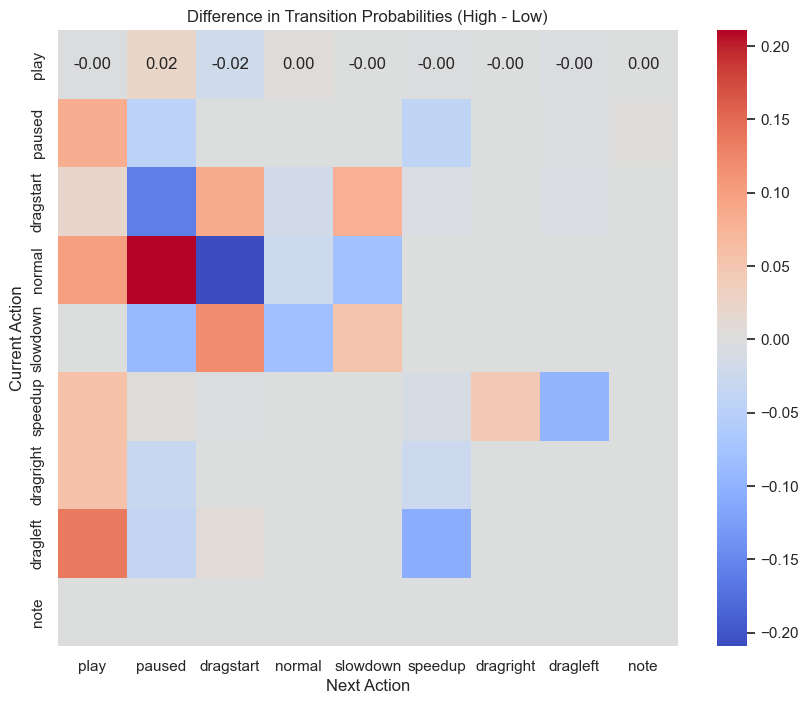

In [23]:
# 假設 high_score_transition_probability_df 和 low_score_transition_probability_df 為高低分組的轉移概率矩陣
# 計算差異矩陣
difference_matrix = high_score_transition_probability_df - low_score_transition_probability_df

# 將差異矩陣視覺化為熱圖
plt.figure(figsize=(10, 8))
sns.heatmap(difference_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Difference in Transition Probabilities (High - Low)")
plt.xlabel("Next Action")
plt.ylabel("Current Action")
plt.show()


In [39]:
high_count = filtered_high_score_transition_count_df_updated.loc['normal', 'paused']
low_count = filtered_low_score_transition_count_df_updated.loc['normal', 'paused']
high_other = filtered_high_score_transition_count_df_updated.values.sum() - high_count
low_other = filtered_low_score_transition_count_df_updated.values.sum() - low_count

In [50]:
from scipy.stats import fisher_exact
import scipy.stats as stats

# Define a function to perform Fisher's exact test for a specific transition
def fisher_test_for_transition(current_action, next_action, high_score_df, low_score_df):
    # Extract counts for the specified transition
    high_count = high_score_df.loc[current_action, next_action]
    low_count = low_score_df.loc[current_action, next_action]

    # Calculate "other" counts for high and low groups
    high_other = high_score_df.values.sum() - high_count
    low_other = low_score_df.values.sum() - low_count

    # Construct 2x2 table
    table = [[high_count, high_other], [low_count, low_other]]

    # Perform Fisher's exact test
    _, p_value = stats.fisher_exact(table)

    # Return the results
    return {
        "Current Action": current_action,
        "Next Action": next_action,
        "High Count": high_count,
        "Low Count": low_count,
        "High Other": high_other,
        "Low Other": low_other,
        "P-Value": round(p_value, 4)
    }

# Define actions to analyze
actions = ['play', 'paused', 'dragstart', 'normal', 'slowdown', 'speedup', 'dragright', 'dragleft', 'note']

# Store results for all transitions
fisher_results_list = []

# Apply Fisher's exact test for each pair of transitions
for current_action in actions:
    for next_action in actions:
        result = fisher_test_for_transition(
            current_action,
            next_action,
            filtered_high_score_transition_count_df_updated,
            filtered_low_score_transition_count_df_updated
        )
        fisher_results_list.append(result)

# Convert results to a DataFrame for better readability
fisher_results_df = pd.DataFrame(fisher_results_list)
significant_transitions = fisher_results_df[fisher_results_df['P-Value'] < 0.05].reset_index(drop=True)
significant_transitions

,Current Action,Next Action,High Count,Low Count,High Other,Low Other,P-Value
0,play,paused,1628.0,2552.0,2414.0,4368.0,0.0004
1,play,normal,59.0,150.0,3983.0,6770.0,0.0091
2,paused,play,1481.0,2184.0,2561.0,4736.0,0.0000
3,paused,paused,39.0,191.0,4003.0,6729.0,0.0000
4,paused,dragstart,183.0,412.0,3859.0,6508.0,0.0014
5,paused,note,7.0,1.0,4035.0,6919.0,0.0050
6,dragstart,dragleft,126.0,384.0,3916.0,6536.0,0.0000
7,normal,normal,13.0,3.0,4029.0,6917.0,0.0004
8,normal,slowdown,30.0,30.0,4012.0,6890.0,0.0434
9,slowdown,normal,50.0,55.0,3992.0,6865.0,0.0251


In [29]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 假設 high_score_action_counts 和 low_score_action_counts 是高低分組的行為次數 DataFrame
# 每一列是不同的行為，如 'play', 'paused', 等

# 定義行為列表
actions = ['play', 'paused', 'dragstart', 'normal', 'slowdown', 'speedup', 'dragright', 'dragleft', 'note']

# 創建一個 DataFrame 來存儲 Fisher’s exact test 的結果
fisher_results = pd.DataFrame(columns=['Action', 'p-value'])

# 對每個行為進行 Fisher’s exact test
for action in actions:
    # 計算高分組和低分組的該行為次數
    high_count = high_score_data_nogroup[action].sum()
    low_count = low_score_data_nogroup[action].sum()
    
    # 計算高低分組其他行為次數的總和
    high_other = high_score_data_nogroup.values.sum() - high_count
    low_other = low_score_data_nogroup.values.sum() - low_count
    
    # 構建 2x2 表格
    table = [[high_count, high_other], [low_count, low_other]]
    
    # 進行 Fisher’s exact test
    _, p_value = stats.fisher_exact(table)
    
    # 將 p-value 四捨五入至小數點第四位
    rounded_p_value = round(p_value, 4)
    
    # 將結果添加到 DataFrame
    fisher_results = pd.concat([fisher_results, pd.DataFrame({
        'Action': [action],
        'p-value': [rounded_p_value]
    })], ignore_index=True)

# 顯示顯著的行為次數差異（p-value < 0.05）
significant_actions = fisher_results[fisher_results['p-value'] < 0.05]
significant_actions.reset_index(drop=True)


C:\Users\USER\AppData\Local\Temp\ipykernel_14976\473484374.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fisher_results = pd.concat([fisher_results, pd.DataFrame({


,Action,p-value
0,play,0.0073
1,dragstart,0.0000
2,dragleft,0.0000
3,note,0.0047


費雪精確檢驗在高分組與低分組的特定行為差異

In [56]:
# Perform Chi-Square test for each action-to-action pair while handling zero expected values
significant_results = []

for action_from in selected_actions_updated:
    for action_to in selected_actions_updated:
        # Create contingency table for the transition
        high_score_count = filtered_high_score_transition_count_df_updated.loc[action_from, action_to]
        low_score_count = filtered_low_score_transition_count_df_updated.loc[action_from, action_to]
        total_high_score = sum(filtered_high_score_transition_count_df_updated.loc[action_from])
        total_low_score = sum(filtered_low_score_transition_count_df_updated.loc[action_from])

        # Skip transitions where total counts are zero
        if total_high_score == 0 or total_low_score == 0:
            continue

        contingency_table = [
            [high_score_count, total_high_score - high_score_count],
            [low_score_count, total_low_score - low_score_count]
        ]

        # Perform Chi-Square test
        try:
            chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

            # Check for significance
            if p_value < 0.05:
                significant_results.append({
                    'From': action_from,
                    'To': action_to,
                    'Chi2 Stat': chi2_stat,
                    'P-Value': p_value
                })
        except ValueError:
            # Skip transitions with invalid contingency tables
            continue

# Convert results to DataFrame for better readability
significant_results_df = pd.DataFrame(significant_results)
significant_results_df

,From,To,Chi2 Stat,P-Value
0,play,paused,8.020749,4.624445e-03
1,play,normal,9.032544,2.652151e-03
2,paused,play,47.704392,4.955801e-12
3,paused,paused,44.534131,2.499613e-11
4,paused,dragstart,14.827316,1.178166e-04
5,paused,note,6.369887,1.160730e-02
6,normal,paused,7.636673,5.719331e-03
7,normal,normal,10.395504,1.263225e-03
8,speedup,normal,5.958177,1.464918e-02
9,dragstart,play,6.025579,1.410000e-02


In [68]:
from scipy.stats import ttest_ind
import pandas as pd

# Define actions to test
actions_to_test = ['play', 'paused', 'dragstart', 'normal', 'slowdown', 'speedup', 'dragright', 'dragleft', 'note']

# Define a function to calculate transition counts for each behavior pair
def calculate_review_transition_counts(df, action_from, action_to):
    # Ensure the 'next_action' column exists
    if 'next_action' not in df.columns:
        df = df.sort_values(by=['review_sn', 'timestamp'])
        df['next_action'] = df.groupby('review_sn')['view_action'].shift(-1)
    
    # Filter rows where the current action is 'action_from' and the next action is 'action_to'
    filtered_df = df[
        (df['view_action'] == action_from) & 
        (df['next_action'] == action_to) & 
        (df['next_action'].notna())
    ]
    # Count transitions per review_sn
    transition_counts = filtered_df.groupby('review_sn').size()
    # Fill missing review_sn with 0 counts
    all_reviews = df['review_sn'].unique()
    transition_counts = transition_counts.reindex(all_reviews, fill_value=0)
    return transition_counts

# Define a function to perform T-tests for all behavior transitions
def t_test_for_transitions(high_df, low_df, actions):
    significant_results = []
    
    # Loop through all pairs of actions
    for action_from in actions:
        for action_to in actions:
            # Calculate transition counts for high and low score groups
            high_counts = calculate_review_transition_counts(high_df, action_from, action_to)
            low_counts = calculate_review_transition_counts(low_df, action_from, action_to)
            
            # Perform T-test
            t_stat, p_value = ttest_ind(high_counts, low_counts, equal_var=False)
            
            # Check for significance
            if p_value < 0.05:
                significant_results.append({
                    'From': action_from,
                    'To': action_to,
                    'T-Stat': t_stat,
                    'P-Value': p_value
                })
    
    # Convert results to DataFrame
    return pd.DataFrame(significant_results)

# Perform T-tests for all behavior transitions
significant_t_test_results = t_test_for_transitions(
    filtered_high_score_review_plus, filtered_low_score_review_plus, actions_to_test
)

# Display the significant results
significant_t_test_results


,From,To,T-Stat,P-Value
0,play,play,2.062829,0.039563
1,play,paused,3.042761,0.002485
2,play,speedup,2.088597,0.037275
3,paused,dragleft,-3.116554,0.001885
4,dragstart,play,-2.754084,0.005995
5,dragstart,normal,-2.004554,0.045418
6,dragstart,dragleft,-3.182209,0.001511
7,speedup,normal,-2.126959,0.033793
8,dragright,paused,-2.126959,0.033793
9,dragleft,paused,-3.026252,0.002544


In [74]:
# Re-import libraries
import pandas as pd
from scipy.stats import fisher_exact

# Redefine required data for context
# Define user groups
low_score_users = [232372, 200920, 38371, 128932, 212767, 311086, 122416, 122299, 106735, 11303, 14503]
high_score_users = [4561, 316786, 32737, 11312, 50836, 243283, 17422, 288079]
relevant_actions = ['play', 'paused', 'normal', 'speedup', 'slowdown', 'dragstart', 'dragright', 'dragleft', 'note']

# Placeholder: Example `user_action_counts` (replace with actual dataframe if available)
user_action_counts = pd.DataFrame({
    'user_sn': high_score_users + low_score_users,
    'play': [50, 40, 30, 20, 10, 15, 25, 35, 12, 8, 9, 5, 6, 10, 7, 4, 3, 2, 1],
    'paused': [20, 15, 10, 5, 8, 9, 11, 13, 5, 2, 3, 2, 1, 1, 1, 1, 0, 0, 0],
    'normal': [5, 5, 5, 5, 4, 3, 3, 3, 2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0]
})
user_action_counts.set_index('user_sn', inplace=True)

# Function to perform Fisher's exact test for all relevant actions
def fisher_test_for_actions(actions, user_action_counts, high_users, low_users):
    significant_results = []
    
    for action in actions:
        # Calculate total counts for the action in high and low score groups
        high_score_total = user_action_counts.loc[high_users, action].sum()
        low_score_total = user_action_counts.loc[low_users, action].sum()
        
        # Calculate total counts for other actions
        high_score_other = user_action_counts.loc[high_users, :].sum().sum() - high_score_total
        low_score_other = user_action_counts.loc[low_users, :].sum().sum() - low_score_total
        
        # Construct contingency table
        contingency_table = [
            [high_score_total, high_score_other],
            [low_score_total, low_score_other]
        ]
        
        # Perform Fisher's exact test
        odds_ratio, p_value = fisher_exact(contingency_table, alternative='two-sided')
        
        # Record only significant results
        if p_value < 0.05:
            significant_results.append({
                'Action': action,
                'High Total': high_score_total,
                'Low Total': low_score_total,
                'Odds Ratio': odds_ratio,
                'P-Value': p_value
            })
    
    return pd.DataFrame(significant_results)

# Apply the function to relevant actions
significant_fisher_results = fisher_test_for_actions(
    relevant_actions, user_action_counts, high_score_users, low_score_users
)


KeyError: 'speedup'